# A gallery of cavity shapes

cavsim2d is not limited to elliptical cavities. Every geometry — elliptical, **flat-top**, **spline (Bezier)**, **RF gun**, pillbox — builds a common `profile()` and so shares the *same* API: `cav.eigenmode.run(...)`, `cav.tune`, `cav.wakefield`, UQ and optimisation all work unchanged. This notebook builds three shapes not shown elsewhere and solves each fundamental mode through the identical call.

In [1]:
import os, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cavsim2d import Study, EllipticalCavityFlatTop, SplineCavity, RFGun
from cavsim2d.utils.style import apply_style
apply_style()

def fundamental(cav, name):
    '''Solve the monopole and return the fundamental freq + R/Q as a row.'''
    study = Study(os.path.join(tempfile.mkdtemp(), name))
    study.add_cavity([cav], [name])
    study.run_eigenmode({'processes': 1, 'boundary_conditions': 'mm',
                         'mesh_config': {'h': 10, 'p': 2}})
    q = cav.eigenmode.qois
    return {'freq [MHz]': q['freq [MHz]'], 'R/Q [Ohm]': q['R/Q [Ohm]'],
            'Epk/Eacc []': q['Epk/Eacc []']}

## 1. Flat-top elliptical

An elliptical cell with a straight flat section at the equator — eight parameters `[A, B, a, b, Ri, L, Req, l]`, the last being the flat length.

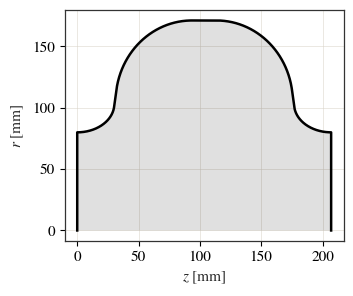

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
ft = [62.22, 66.13, 30.22, 23.11, 80, 93.5, 171.20, 20]
flat = EllipticalCavityFlatTop(1, ft, ft, ft, beampipe='none', name='flattop')
flat.plot('geometry')

In [3]:
row_ft = fundamental(flat, 'flattop'); row_ft

{'freq [MHz]': 796.3470914042377,
 'R/Q [Ohm]': 94.78932536488439,
 'Epk/Eacc []': 2.136414777989721}

## 2. Spline (Bezier) cavity

A free-form wall defined by control points and fitted with a Bezier spline — for shapes the elliptical parameterisation can't express.

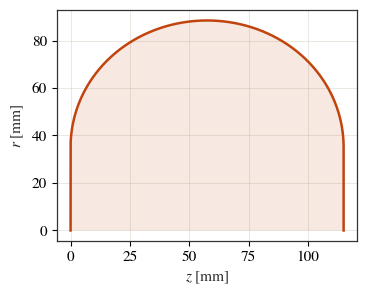

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [4]:
geom = {'p0': [0, 35], 'p1': [0, 70], 'p2': [30, 103],
        'p3': [85, 103], 'p4': [115, 70], 'p5': [115, 35]}
spline = SplineCavity({'geometry': dict(geom)}, kind='Bezier')
spline.name = 'spline'
spline.plot('geometry')

In [5]:
row_sp = fundamental(spline, 'spline'); row_sp

{'freq [MHz]': 1534.5573276089435,
 'R/Q [Ohm]': 103.23637568995248,
 'Epk/Eacc []': 6.313393732419441}

## 3. RF gun

A photoinjector gun geometry (dimensions in metres, angles in radians) — a very different beast, but the same eigenmode call finds its VHF accelerating mode.

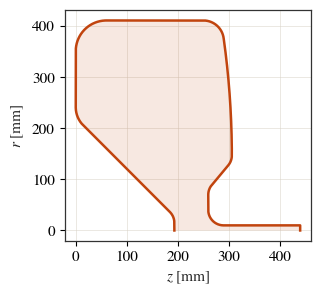

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [6]:
gun = {'geometry': {'y1': 1.5e-2, 'R2': 3e-2, 'T2': np.deg2rad(45), 'L3': 24e-2,
                    'R4': 5e-2, 'L5': 11e-2, 'R6': 6e-2, 'L7': 19e-2, 'R8': 4e-2,
                    'T9': np.deg2rad(8), 'R10': 3e-2, 'T10': np.deg2rad(40),
                    'L11': 5e-2, 'R12': 3e-2, 'L13': 3e-2, 'R14': 3e-2, 'x': 1e-2}}
rfgun = RFGun(gun); rfgun.name = 'rfgun'
rfgun.plot('geometry')

In [7]:
row_gun = fundamental(rfgun, 'rfgun'); row_gun

{'freq [MHz]': 213.06834851302116,
 'R/Q [Ohm]': 133.66762013858826,
 'Epk/Eacc []': 16.866599375611564}

## The same API, four geometries

Each shape solved through the identical `run_eigenmode` call:

In [8]:
pd.DataFrame({'flat-top': row_ft, 'spline': row_sp, 'RF gun': row_gun}).T.round(3)

,freq [MHz],R/Q [Ohm],Epk/Eacc []
flat-top,796.347,94.789,2.136
spline,1534.557,103.236,6.313
RF gun,213.068,133.668,16.867


## Where to go next

- [The TESLA elliptical cavity](elliptical_tesla.ipynb) and [the pillbox / circular waveguide](pillbox.ipynb).
- Every one of these types also tunes, runs wakefields, and takes a `uq_config` — see [Eigenmode under uncertainty](../advanced/eigenmode_uq.ipynb) (spline + RF gun) and [Robust tuning](../advanced/robust_tuning.ipynb) (flat-top).